# BindCurve basics

This notebook shows the core workflow: build `DoseResponseData`, fit a model, inspect `FitResults`, and plot curves/residuals. The data are synthetic.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bindcurve as bc

The following settings adjust the decimals and display width for pandas. This is just for display purposes, all numbers will still be stored with many decimal places.

In [44]:
pd.set_option("display.precision", 2)
pd.set_option('display.width', 200)

## Create `DoseResponseData` from csv file


In [45]:
data = bc.DoseResponseData.from_csv(
    "tutorial_data/galectin/competitive_binding.csv", 
    format="wide",
)

data.summary()


,compound_id,N_exp,N_obs,N_conc_total,concentration_min,concentration_max,response_min,response_max
0,CB-XII,3,108,12,1.20e-03,400.0,19.0,96.0
1,JZ3-28,3,108,12,1.20e-03,400.0,28.0,97.0
2,JZ7-61-2,3,108,12,1.20e-03,400.0,16.0,96.0
3,JZ7-62,3,107,12,1.20e-03,400.0,16.0,97.0
4,JZ8-14,3,108,12,1.20e-03,400.0,15.0,93.0
5,JZ8-48,3,107,12,1.20e-03,400.0,21.0,102.0
6,JZ8-55,1,36,12,1.20e-03,400.0,79.0,92.0
7,JZ9-38,3,108,14,1.20e-03,800.0,43.0,98.0
8,TD139,3,102,12,1.20e-03,400.0,20.0,98.0
9,TDG,3,102,12,1.20e-03,400.0,41.0,97.0


In [46]:
data.quality_report()

,compound_id,status,N_flag_orange,N_flag_red,flags,N_exp,N_obs,N_conc_union,N_conc_min,N_conc_median,N_conc_max,grid_coverage,N_rep_min,N_rep_median,N_rep_max,single_replicate_fraction,intra_noise_median_frac_range,intra_noise_p90_frac_range,nonpositive_concentration_count
0,CB-XII,green,0,0,,3,108,12,12,12.0,12,1.00,3,3.0,3,0.0,0.04,0.07,0
1,JZ3-28,green,0,0,,3,108,12,12,12.0,12,1.00,3,3.0,3,0.0,0.04,0.07,0
2,JZ7-61-2,green,0,0,,3,108,12,12,12.0,12,1.00,3,3.0,3,0.0,0.04,0.07,0
3,JZ7-62,green,0,0,,3,107,12,12,12.0,12,1.00,2,3.0,3,0.0,0.04,0.06,0
4,JZ8-14,green,0,0,,3,108,12,12,12.0,12,1.00,3,3.0,3,0.0,0.04,0.08,0
5,JZ8-48,green,0,0,,3,107,12,12,12.0,12,1.00,2,3.0,3,0.0,0.03,0.05,0
6,JZ8-55,red,0,3,fewer than 2 independent experiments; high med...,1,36,12,12,12.0,12,1.00,3,3.0,3,0.0,0.72,0.93,0
7,JZ9-38,orange,3,0,incomplete experiment-concentration grid; elev...,3,108,14,12,12.0,12,0.86,3,3.0,3,0.0,0.07,0.11,0
8,TD139,orange,1,0,incomplete experiment-concentration grid,3,102,12,10,12.0,12,0.94,3,3.0,3,0.0,0.03,0.06,0
9,TDG,orange,2,0,incomplete experiment-concentration grid; elev...,3,102,12,10,12.0,12,0.94,3,3.0,3,0.0,0.06,0.09,0


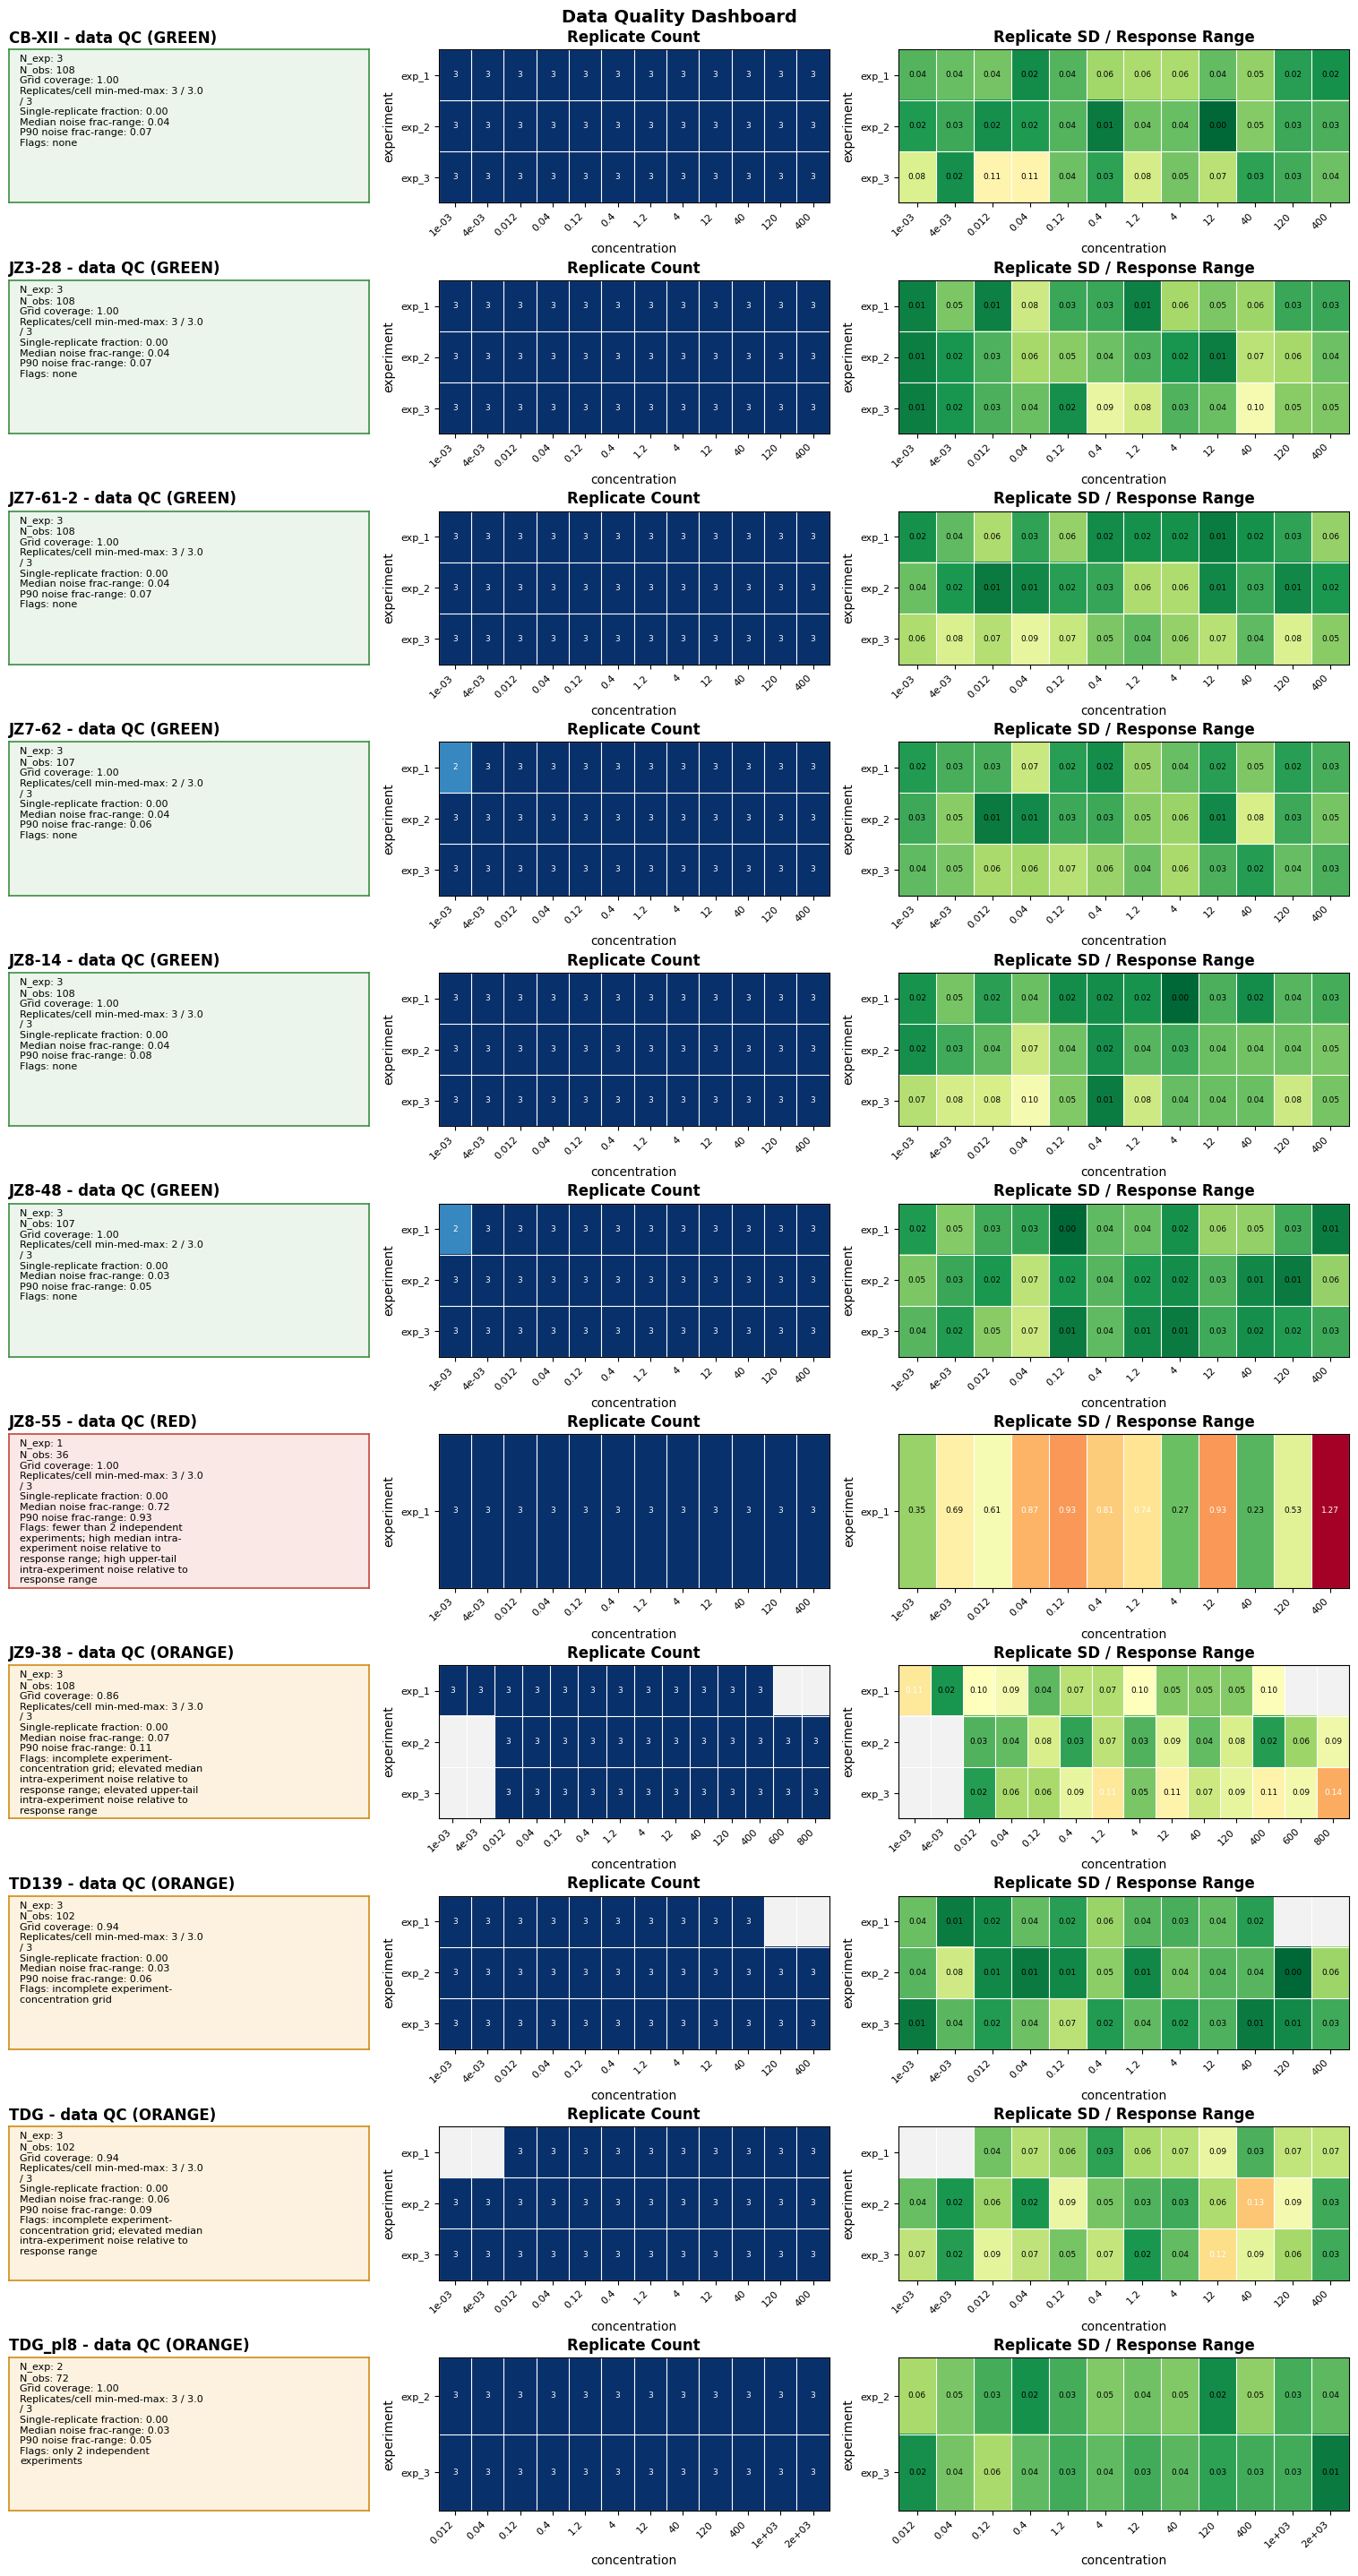

In [47]:
data.quality_dashboard()

## Fit the dose-response model

Bindcurve fits one curve per independent experiment and averages technical replicates at each concentration.

In [48]:
results = bc.fit(
    data,
    model='ic50', 
)

results.summary()

,compound_id,N_exp,N_obs,ymin,ymin_SD,ymin_SEM,ymin_CI95_lower,ymin_CI95_upper,ymax,ymax_SD,...,IC50_SEM_upper,IC50_CI95_lower,IC50_CI95_upper,hill_slope,hill_slope_SD,hill_slope_SEM,hill_slope_CI95_lower,hill_slope_CI95_upper,R_squared,Chi_squared
0,CB-XII,3,36,22.37,2.43,1.40,16.34,28.40,89.11,3.78,...,4.47,4.13,4.70,-1.00,0.10,5.58e-02,-1.24,-0.76,1.00,50.32
1,JZ3-28,3,36,22.04,3.17,1.83,14.16,29.92,89.94,2.85,...,89.10,79.45,95.68,-1.01,0.05,2.64e-02,-1.12,-0.89,1.00,54.41
2,JZ7-61-2,3,36,21.54,0.16,0.09,21.14,21.94,89.06,3.69,...,2.56,2.12,2.89,-0.97,0.07,3.94e-02,-1.14,-0.80,1.00,60.32
3,JZ7-62,3,36,21.89,3.50,2.02,13.20,30.58,90.15,3.44,...,3.74,2.33,5.01,-1.03,0.14,8.25e-02,-1.39,-0.68,1.00,56.21
4,JZ8-14,3,36,22.73,1.44,0.83,19.15,26.30,85.41,4.66,...,0.09,0.07,0.10,-1.62,0.12,6.95e-02,-1.91,-1.32,1.00,60.83
5,JZ8-48,3,36,23.11,0.94,0.54,20.78,25.43,89.95,3.73,...,3.92,3.24,4.41,-0.99,0.04,2.25e-02,-1.08,-0.89,1.00,84.22
6,JZ8-55,1,12,84.40,NaN,NaN,NaN,NaN,86.11,NaN,...,NaN,NaN,NaN,-1.56,NaN,NaN,NaN,NaN,0.39,10.75
7,JZ9-38,3,36,17.94,1.64,0.95,13.87,22.01,89.08,4.02,...,584.99,495.18,648.99,-0.99,0.01,7.86e-03,-1.03,-0.96,0.98,80.81
8,TD139,3,34,24.43,1.25,0.72,21.32,27.54,90.06,2.47,...,0.09,0.06,0.11,-1.88,0.10,5.58e-02,-2.13,-1.64,1.00,54.59
9,TDG,3,34,44.79,2.29,1.32,39.11,50.48,91.53,2.48,...,30.48,11.46,56.04,-0.99,0.14,7.81e-02,-1.32,-0.65,0.94,580.22


In [49]:
results.parameters()

,compound_id,parameter,summary_type,N_exp,mean,sd,sem,ci95_lower,ci95_upper,log_parameter,...,log10_mean,log10_sd,log10_sem,log10_ci95_lower,log10_ci95_upper,center,sd_lower,sd_upper,sem_lower,sem_upper
0,CB-XII,ymin,native,3,22.37,2.43,1.40e+00,16.34,28.40,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CB-XII,ymax,native,3,89.11,3.78,2.18e+00,79.72,98.50,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CB-XII,IC50,concentration,3,NaN,NaN,NaN,4.13,4.70,logIC50,...,0.64,1.14e-02,6.61e-03,0.62,0.67,4.41,4.29,4.52,4.34,4.47
3,CB-XII,hill_slope,native,3,-1.00,0.10,5.58e-02,-1.24,-0.76,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,JZ3-28,ymin,native,3,22.04,3.17,1.83e+00,14.16,29.92,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,JZ3-28,ymax,native,3,89.94,2.85,1.64e+00,82.87,97.01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,JZ3-28,IC50,concentration,3,NaN,NaN,NaN,79.45,95.68,logIC50,...,1.94,1.62e-02,9.38e-03,1.90,1.98,87.19,83.99,90.52,85.33,89.10
7,JZ3-28,hill_slope,native,3,-1.01,0.05,2.64e-02,-1.12,-0.89,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,JZ7-61-2,ymin,native,3,21.54,0.16,9.30e-02,21.14,21.94,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,JZ7-61-2,ymax,native,3,89.06,3.69,2.13e+00,79.88,98.23,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
results.fit_summary()

,compound_id,experiment_id,model,success,message,n_data,n_varying_parameters,chisqr,redchi,aic,bic,r_squared,ymin,ymin_stderr,ymax,ymax_stderr,IC50,IC50_stderr,hill_slope,hill_slope_stderr
0,CB-XII,exp_1,ic50,True,Fit succeeded.,12,4,28.97,3.62,18.58,20.52,1.00,25.05,1.52,86.06,0.89,4.45,4.71e-01,-1.10,0.11
1,CB-XII,exp_2,ic50,True,Fit succeeded.,12,4,11.83,1.48,7.82,9.76,1.00,21.73,1.14,93.34,0.62,4.28,3.00e-01,-0.91,0.05
2,CB-XII,exp_3,ic50,True,Fit succeeded.,12,4,9.53,1.19,5.23,7.17,1.00,20.33,0.97,87.94,0.53,4.50,2.78e-01,-0.98,0.05
3,JZ3-28,exp_1,ic50,True,Fit succeeded.,12,4,21.20,2.65,14.83,16.77,0.99,24.53,6.44,87.25,0.66,84.24,2.32e+01,-0.96,0.14
4,JZ3-28,exp_2,ic50,True,Fit succeeded.,12,4,9.05,1.13,4.62,6.56,1.00,23.13,3.88,92.92,0.42,86.73,1.22e+01,-1.04,0.09
5,JZ3-28,exp_3,ic50,True,Fit succeeded.,12,4,24.15,3.02,16.39,18.33,0.99,18.47,6.73,89.65,0.68,90.73,2.16e+01,-1.03,0.14
6,JZ7-61-2,exp_1,ic50,True,Fit succeeded.,12,4,26.35,3.29,17.44,19.38,1.00,21.66,1.47,85.74,0.96,2.63,2.90e-01,-0.93,0.08
7,JZ7-61-2,exp_2,ic50,True,Fit succeeded.,12,4,12.23,1.53,8.23,10.17,1.00,21.35,0.98,93.04,0.66,2.32,1.55e-01,-0.93,0.05
8,JZ7-61-2,exp_3,ic50,True,Fit succeeded.,12,4,21.73,2.72,15.13,17.07,1.00,21.60,1.20,88.39,0.83,2.48,2.12e-01,-1.05,0.08
9,JZ7-62,exp_1,ic50,True,Fit succeeded.,12,4,23.75,2.97,16.19,18.13,1.00,23.94,1.28,86.28,0.84,3.12,2.91e-01,-1.09,0.10


## Manuscript-ready report

Bindcurve provides convenient tooling to report your results in formated report that are ready to copy paste in your paper or report.

In [51]:
results.report()

,compound_id,report
0,CB-XII,"4.4 [4, 5]"
1,JZ3-28,"87 [8e+01, 9e+01]"
2,JZ7-61-2,"2.5 [2, 3]"
3,JZ7-62,"3.4 [3, 4]"
4,JZ8-14,"0.083 [0.08, 0.09]"
5,JZ8-48,"3.8 [4, 4]"
6,JZ8-55,2.6
7,JZ9-38,"5.7e+02 [5e+02, 6e+02]"
8,TD139,"0.079 [0.07, 0.09]"
9,TDG,"25 [2e+01, 3e+01]"


In [52]:
results.quality_report()

,compound_id,status,N_flag_orange,N_flag_red,flags,parameter,N_exp,N_fit_success,N_fit_failed,fit_success_fraction,...,Chi_squared_total,redchi_median,covariance_missing_fraction,stderr_missing_fraction,parameter_at_bound_fraction,inter_log10_sd,inter_log10_sem,inter_log10_ci95_width,inter_sd_fold,inter_ci95_fold
0,CB-XII,green,0,0,,IC50,3,3,0,1.0,...,50.32,1.48,0.0,0.0,0.0,1.14e-02,6.61e-03,0.06,1.05,1.14
1,JZ3-28,green,0,0,,IC50,3,3,0,1.0,...,54.41,2.65,0.0,0.0,0.0,1.62e-02,9.38e-03,0.08,1.08,1.20
2,JZ7-61-2,green,0,0,,IC50,3,3,0,1.0,...,60.32,2.72,0.0,0.0,0.0,2.71e-02,1.56e-02,0.13,1.13,1.36
3,JZ7-62,green,0,0,,IC50,3,3,0,1.0,...,56.21,2.90,0.0,0.0,0.0,6.67e-02,3.85e-02,0.33,1.36,2.15
4,JZ8-14,green,0,0,,IC50,3,3,0,1.0,...,60.83,1.83,0.0,0.0,0.0,3.93e-02,2.27e-02,0.20,1.20,1.57
5,JZ8-48,green,0,0,,IC50,3,3,0,1.0,...,84.22,2.87,0.0,0.0,0.0,2.69e-02,1.55e-02,0.13,1.13,1.36
6,JZ8-55,red,0,1,fewer than 2 independent experiments,IC50,1,1,0,1.0,...,10.75,1.34,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
7,JZ9-38,green,0,0,,IC50,3,3,0,1.0,...,80.81,3.62,0.0,0.0,0.0,2.36e-02,1.37e-02,0.12,1.12,1.31
8,TD139,green,0,0,,IC50,3,3,0,1.0,...,54.59,1.36,0.0,0.0,0.0,5.55e-02,3.21e-02,0.28,1.29,1.89
9,TDG,orange,1,0,wide inter-experiment CI95 fold range,IC50,3,3,0,1.0,...,580.22,24.80,0.0,0.0,0.0,1.39e-01,8.01e-02,0.69,1.89,4.89


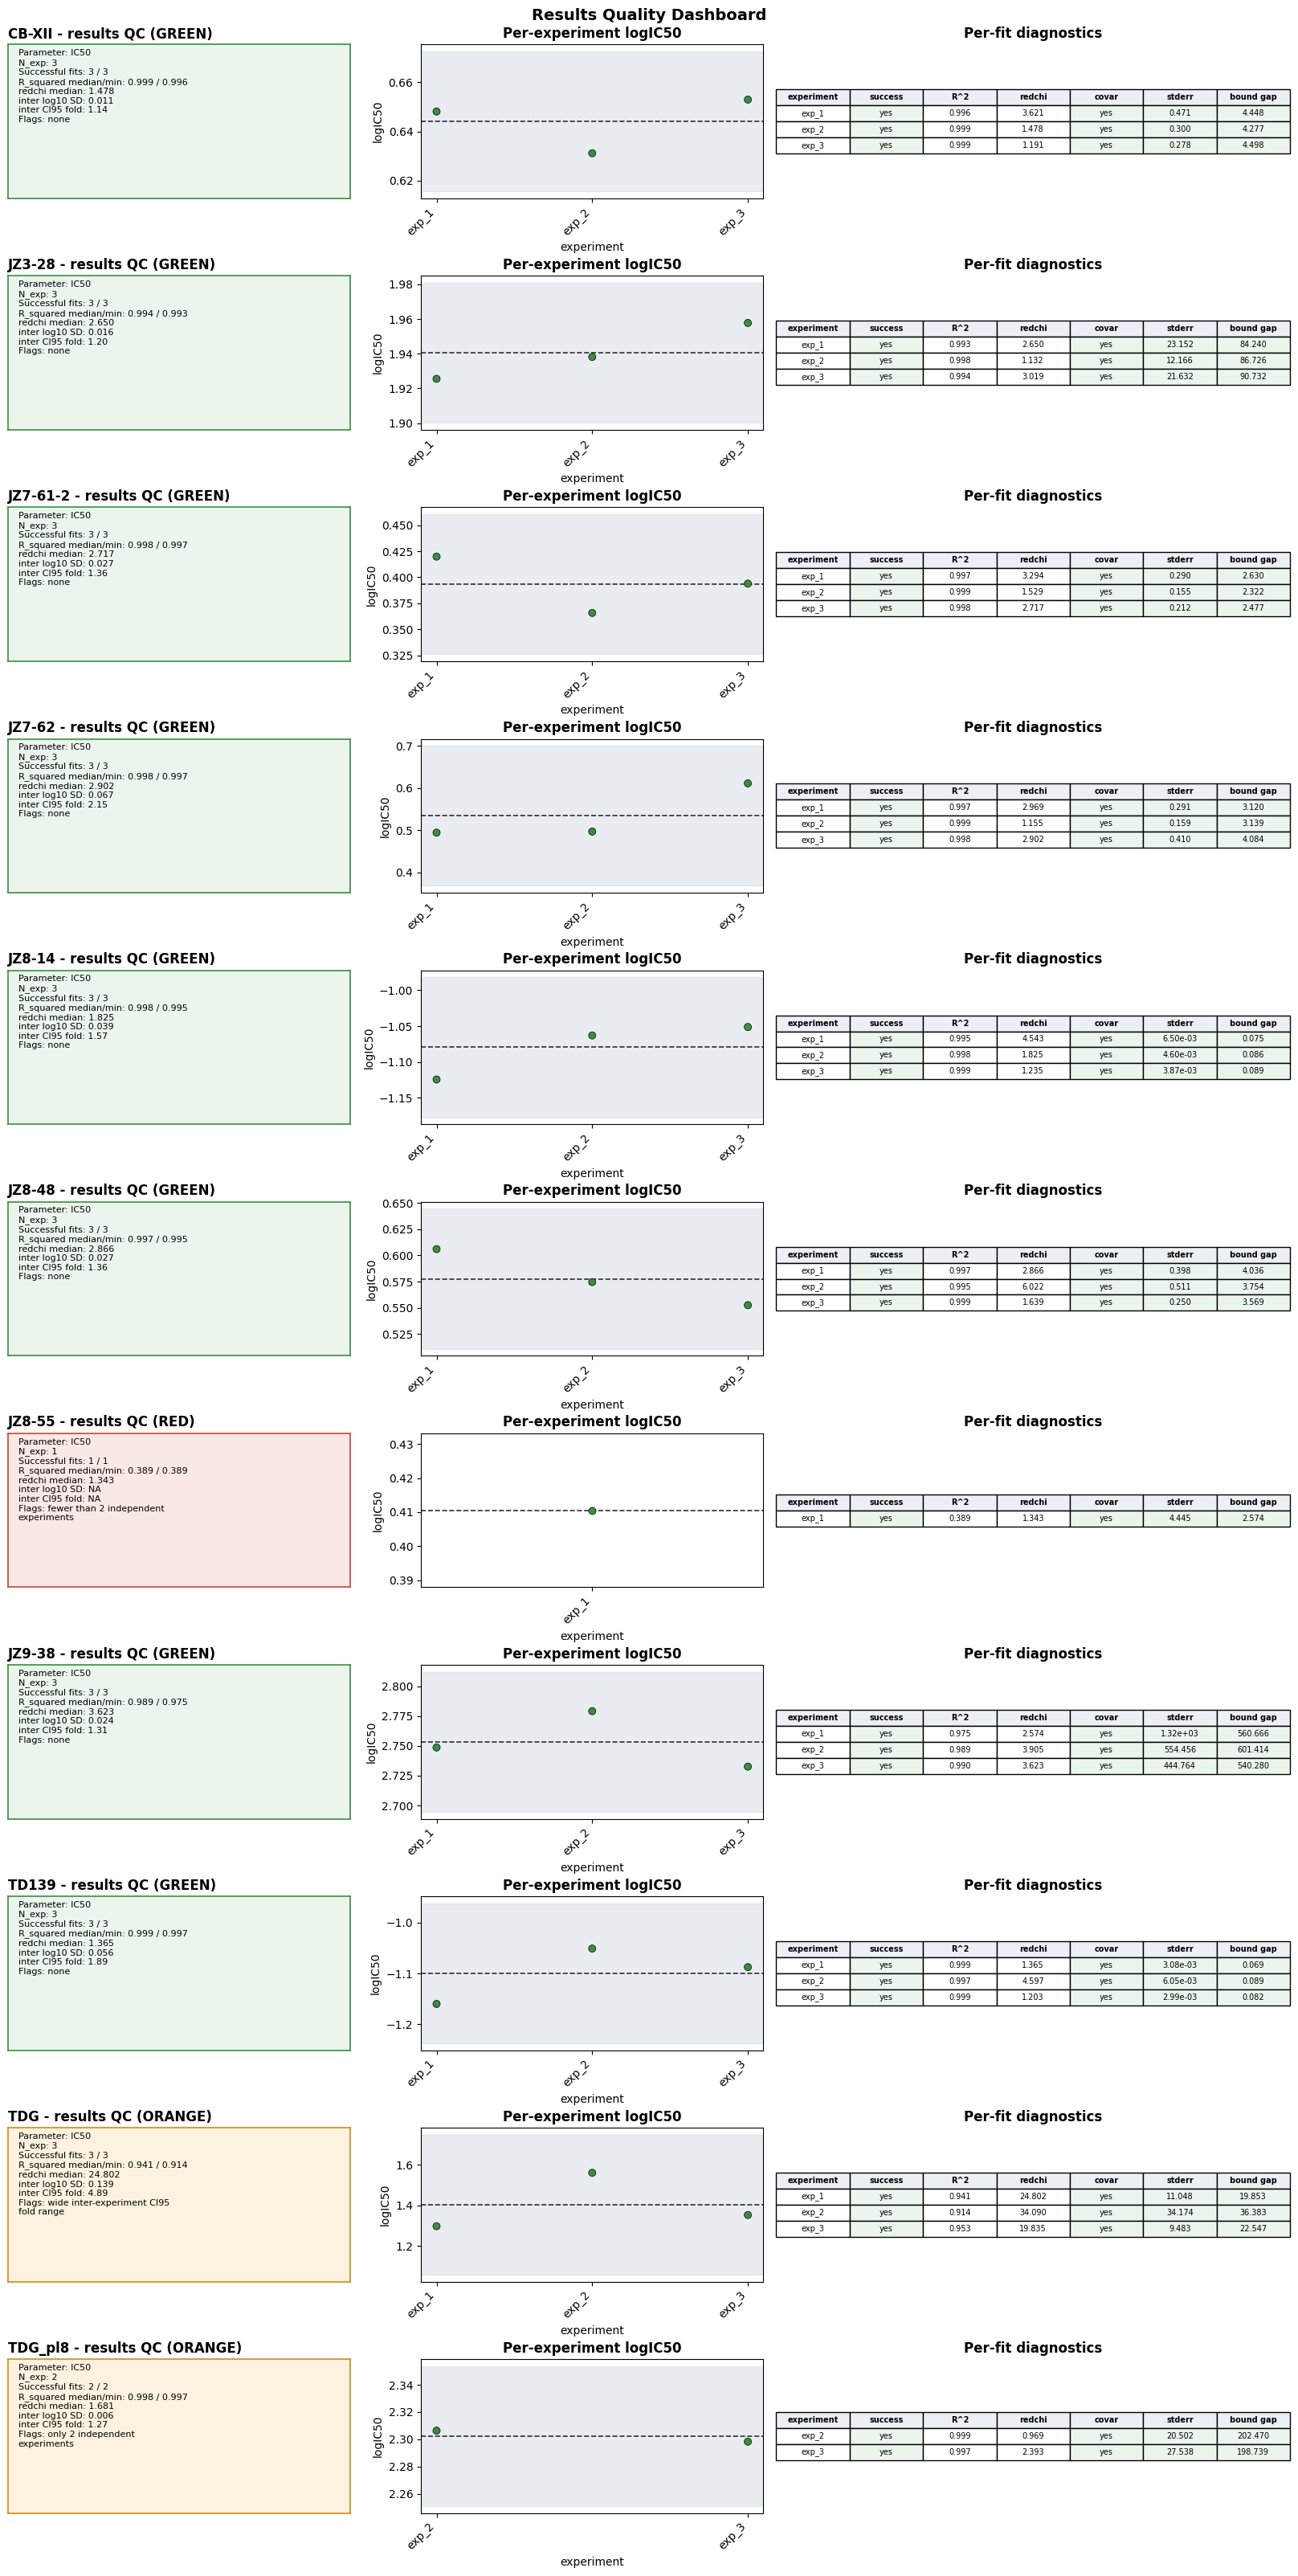

In [53]:
results.quality_dashboard()

## Plot compounds, individual fits, and residuals

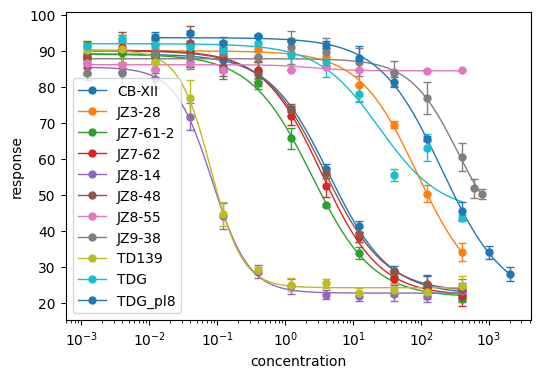

In [54]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_compounds(
    data,
    results,
    compounds=None,
    ax=ax,
)
ax.set_xlabel("concentration")
ax.set_ylabel("response")
ax.legend()
plt.show()

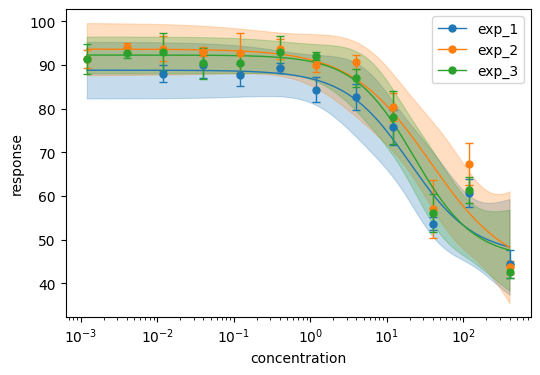

In [57]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_fits(
    data,
    results,
    confidence_band=True,
    ax=ax,
    compounds=["TDG"],
    experiments=["exp_1", "exp_2", "exp_3"],
)
ax.set_xlabel("concentration")
ax.set_ylabel("response")
ax.legend()
plt.show()

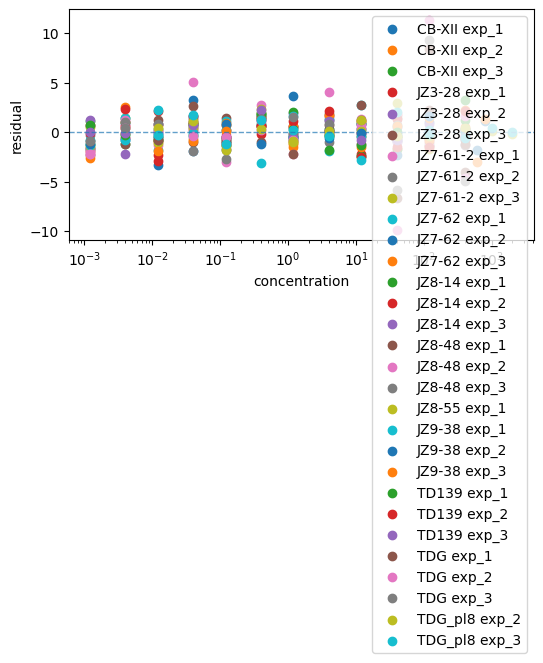

In [56]:
fig, ax = plt.subplots(figsize=(6, 3))
bc.plot_residuals(
    data, 
    results, 
    ax=ax
)
ax.set_xlabel("concentration")
ax.set_ylabel("residual")
ax.legend()
plt.show()